# AMAT-4 — Day 1: SEM Image Formation
## 1. Goal

Build the minimal, focused understanding of how an SEM image is formed — just enough
to reason about what a synthetic-SEM generator needs to reproduce — using the real
**EMPS** dataset as ground truth.

Scope is deliberately narrow (per the project brief): the electron-beam -> sample ->
detector -> pixel signal chain, SE vs. BSE at a conceptual level, and why edges look
bright. Electron-optics derivations, scattering equations, and quantum mechanics are
explicitly out of scope for this notebook.

## 2. Very short SEM image-formation explanation

- A focused electron beam scans the sample in a raster pattern (row by row).
- At each beam position, electrons hit the sample and knock out **secondary electrons (SE)**
  and reflect **backscattered electrons (BSE)**.
- A detector counts how many of these electrons arrive for that beam position.
- That count becomes the brightness of one pixel. Repeat for every raster position -> full image.

**Signal chain:** `electron beam -> sample -> emitted electrons -> detector -> pixel`

Consequence: SEM images are fundamentally a *count* of particles per pixel, not a
continuous light measurement like a camera. This is why Day 2 focuses on Poisson
(counting) statistics for the noise model.

## 3. Dataset examples

Loading a handful of real SEM images from **EMPS** (Electron Microscopy Particle
Segmentation, Yildirim & Cole, 2021) — 465 real electron-microscopy images with
particle segmentation masks, MIT license. This is our ground-truth reference for
everything that follows.

Matplotlib is building the font cache; this may take a moment.


Total EMPS images: 465


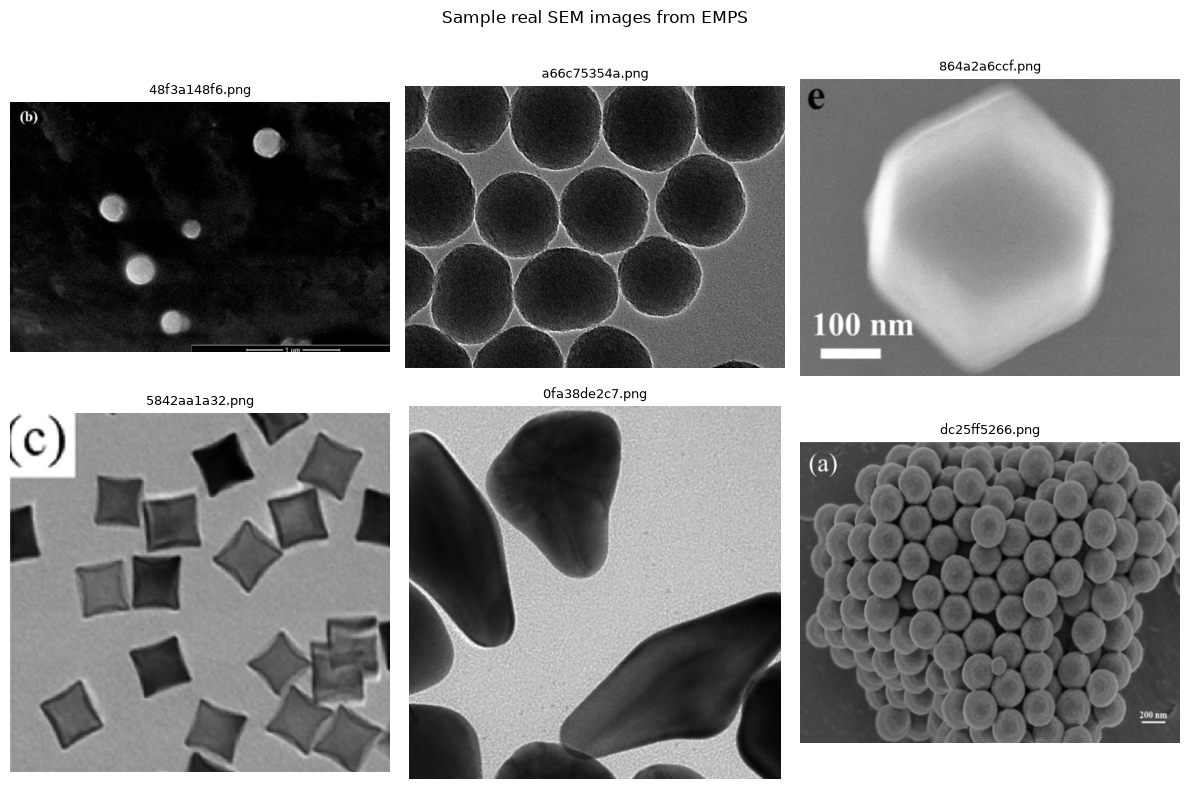

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = os.path.join("emps", "images")
files = sorted(os.listdir(DATA_DIR))
print(f"Total EMPS images: {len(files)}")

rng = np.random.default_rng(0)
sample_files = rng.choice(files, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, fname in zip(axes.ravel(), sample_files):
    img = Image.open(os.path.join(DATA_DIR, fname)).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(fname, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample real SEM images from EMPS")
plt.tight_layout()
plt.show()


## 4. Image metadata / statistics

Basic stats across a sample of images: resolution, dtype, intensity range, mean, std.
This establishes the numeric baseline that any synthetic generator must land inside.

In [2]:
stats_rows = []
sample_files2 = rng.choice(files, size=40, replace=False)
for fname in sample_files2:
    img = np.array(Image.open(os.path.join(DATA_DIR, fname)).convert("L"))
    stats_rows.append({
        "filename": fname,
        "height": img.shape[0],
        "width": img.shape[1],
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(img.mean()),
        "std": float(img.std()),
    })

import pandas as pd
df = pd.DataFrame(stats_rows)
print(df.describe())
df.head()


          height       width        min         max        mean        std
count   40.00000   40.000000  40.000000   40.000000   40.000000  40.000000
mean   512.65000  612.075000   5.025000  253.300000  121.884131  45.170417
std      3.49028   84.032774  12.363071    6.676403   48.326226  18.221697
min    512.00000  512.000000   0.000000  214.000000   44.707648  18.981319
25%    512.00000  514.000000   0.000000  255.000000   86.095447  28.538688
50%    512.00000  611.500000   0.000000  255.000000  119.970813  41.412719
75%    512.00000  688.250000   0.000000  255.000000  160.300285  56.125454
max    534.00000  781.000000  57.000000  255.000000  216.735237  83.133405


,filename,height,width,min,max,mean,std
0,08549eb98f.png,512,512,0,255,87.991192,52.481331
1,d933f429cc.png,512,547,0,255,86.800346,63.506122
2,1ff313314c.png,514,512,57,250,159.266294,35.666083
3,fff35f80e1.png,512,512,21,255,128.471607,27.306236
4,7f50b86c4b.png,512,517,0,255,178.094245,64.393924


## 5. Histograms

Intensity histograms for a few images — real SEM intensity distributions are not
uniform; they cluster around the substrate background level with a tail/peak for
brighter particle edges.

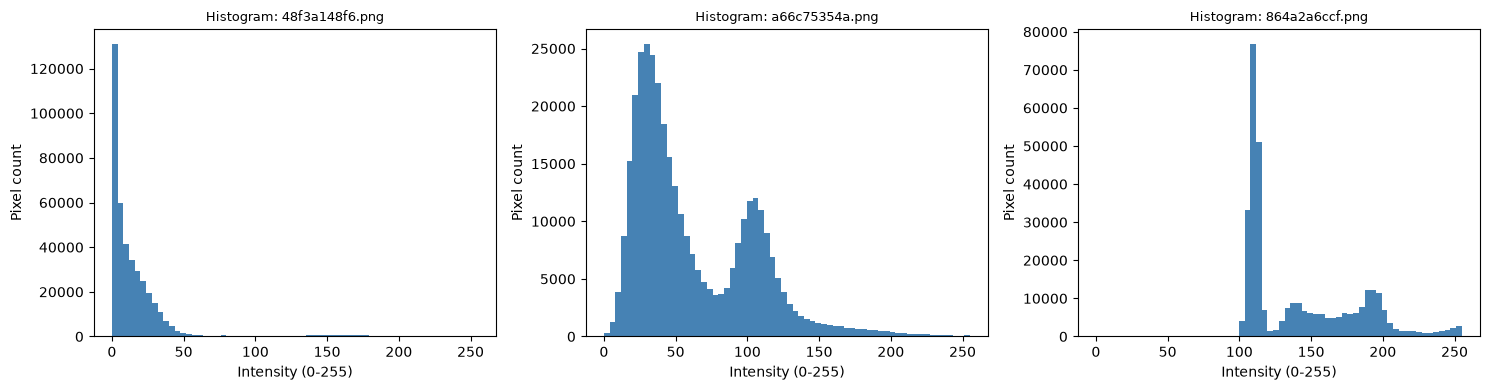

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fname in zip(axes, sample_files[:3]):
    img = np.array(Image.open(os.path.join(DATA_DIR, fname)).convert("L"))
    ax.hist(img.ravel(), bins=64, color="steelblue")
    ax.set_title(f"Histogram: {fname}", fontsize=9)
    ax.set_xlabel("Intensity (0-255)")
    ax.set_ylabel("Pixel count")
plt.tight_layout()
plt.show()


## 6. Zoomed regions

Cropping in on a small patch (e.g. a particle edge) to see pixel-level structure —
grain, edge brightness, local noise texture — that's invisible at full-image scale.

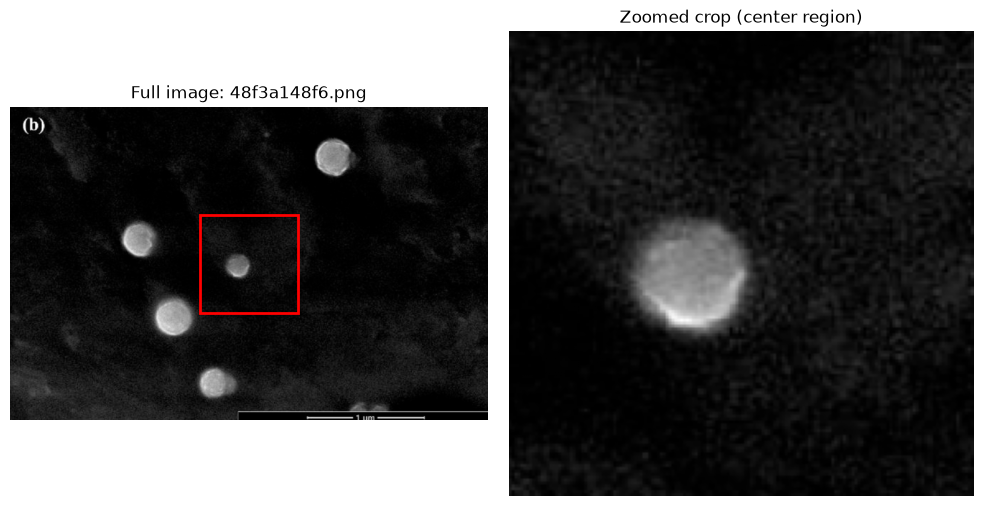

In [4]:
fname = sample_files[0]
img = np.array(Image.open(os.path.join(DATA_DIR, fname)).convert("L"))
h, w = img.shape
cy, cx = h // 2, w // 2
crop_size = 80
crop = img[cy - crop_size:cy + crop_size, cx - crop_size:cx + crop_size]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].add_patch(plt.Rectangle((cx - crop_size, cy - crop_size), 2*crop_size, 2*crop_size,
                                  edgecolor="red", facecolor="none", linewidth=2))
axes[0].set_title(f"Full image: {fname}")
axes[0].axis("off")
axes[1].imshow(crop, cmap="gray")
axes[1].set_title("Zoomed crop (center region)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 7. SEM vs. ordinary photograph

| Aspect | SEM image | Ordinary photograph |
|---|---|---|
| Signal carrier | Electrons (counted) | Photons (light intensity) |
| Color | Grayscale (single detector channel) | RGB (3 color channels) |
| Formation | Raster-scanned point by point | Captured all at once (sensor array) |
| Noise | Poisson (counting) — depends on dose | Mostly photon shot noise + read noise, higher SNR typically |
| Depth of field | Very large (near-parallel electron trajectories) | Limited by lens aperture |
| Illumination model | No real "lighting/shadow" — contrast comes from electron yield vs. surface angle | Illumination + surface reflectance (BRDF) |
| Scale | Nanometers to micrometers | Macroscopic (mm-m) |

The key generative implication: an SEM image generator has to reproduce a
**counting-noise, single-channel, raster-formed signal**, not a lit, multi-channel photo.

## 8. Questions / uncertainties

- What is the actual acquisition dose/scan-rate for the EMPS images? (Not stated in the
  dataset metadata — we cannot directly verify the Poisson noise level against known
  imaging parameters, only infer it from pixel statistics.)
- EMPS images come from many different source papers/instruments (see `doi` column in
  metadata.csv) — should we expect consistent noise statistics across the whole dataset,
  or per-source variation that needs to be modeled separately?
- Segmentation masks give us object shape ground truth, but not a "clean" noise-free
  reference image — how do we separate "real texture" from "detector noise" without one?
  (This maps directly to the ground-truth problem discussed earlier in the project.)
